# Projet 2 — Modélisation temporelle, backtesting et prévision face au marché
## Fonds étudié : Fidelity Magellan Fund (FMAGX) — suite du Projet 1

**Groupe 5** — Économétrie appliquée à la finance

---

### Plan du notebook

| Étape de la méthodologie commune | Volet de l'énoncé | Section |
|---|---|---|
| 1. Présentation du problème et des objectifs | | 1 |
| 2. Collecte des données (traçabilité) | | 2 |
| 3. Construction des variables | | 3 |
| 4. Prétraitement (valeurs manquantes, valeurs aberrantes IQR) | | 4 |
| 5. Analyse exploratoire (stats descriptives, Jarque–Bera, graphiques) | | 5 |
| 6. Validation du modèle du Projet 1 | **Volet A** : Ljung–Box sur les résidus Fama–French | 6 |
| 7. Modélisation | **Volet B** : découpage 80/20, ADF, FAC/FACP, choix de (p, q) par AIC/BIC | 7 |
| 7. Validation et diagnostic du modèle ARMA | Volet B (suite) : Ljung–Box, normalité des résidus | 7 |
| 8. Prévision sur un horizon jamais utilisé pour l'estimation | **Volet C** : `get_forecast(steps=12)` + IC à 95 % | 8 |
| 9. Confrontation à la réalité | **Volet D** : graphique unique, RMSE, MAE, comparaison à la prévision naïve | 9 |
| Pour aller plus loin | backtest glissant, piège du *data snooping*, traduction en valeur liquidative | 9 |
| 10. Bilan critique | | 10 |

Toutes les figures utilisées dans le rapport sont générées par ce notebook et enregistrées dans `figures/`.

## 1. Présentation du problème et des objectifs

### Du statique au dynamique

Dans le Projet 1, nous avons cherché à expliquer le rendement du fonds à l'aide des facteurs de risque du même mois. Cette approche par le modèle de Fama-French était purement statique et descriptive : elle nous indiquait comment le fonds réagissait au marché, mais ne nous permettait pas de faire des prévisions (puisque les facteurs du mois t ne sont connus qu'à la fin de ce même mois).

Pour ce Projet 2, nous changeons d'approche. Nous allons chercher à savoir si les rendements passés contiennent de l'information utile pour prédire les rendements futurs. Pour cela, nous nous appuierons sur les modèles de séries temporelles vus au chapitre 4, et plus particulièrement sur les modèles ARMA.

### Les deux questions posées

Notre travail va s'articuler autour de deux grands axes :

Volet A (le lien avec le Projet 1) : Nous allons vérifier si notre modèle de Fama-French a bien capté toute la structure des rendements. S'il reste une dépendance temporelle dans les résidus (un mois qui "annonce" le suivant), cela signifie qu'il manque des informations. À l'inverse, s'ils forment un simple bruit blanc, notre modèle précédent est validé.

Volets B, C et D (le backtesting) : Nous allons calibrer un modèle ARMA sur les 4 premières années de notre échantillon. Notre but est de voir si ce modèle parvient à mieux prévoir les rendements de la dernière année (qui lui sera volontairement cachée pendant l'estimation) qu'une simple prévision naïve basée sur la moyenne historique.

### Pour qui cette question a-t-elle un sens ?

En pratique, nos résultats pourraient intéresser plusieurs acteurs :

L'investisseur tactique, qui cherche à anticiper le meilleur moment pour entrer ou sortir du fonds en se basant sur les performances récentes.
Le risk manager, pour qui la fourchette de rendements plausibles (l'intervalle de prévision) est cruciale pour estimer les pertes potentielles du mois suivant.
L'auditeur de notre Projet 1, puisque le volet A nous sert de test de validité (des résidus autocorrélés signifieraient que nos écarts-types calculés par les MCO étaient faussés).

### Ce que la théorie financière laisse attendre

D'après l'hypothèse de l'efficience faible des marchés (vue au chapitre 1), toute l'information passée est censée être déjà intégrée dans les prix actuels. Théoriquement, nous ne devrions donc pas pouvoir prévoir les rendements futurs, qui se comporteraient globalement comme un bruit blanc (soit un modèle ARMA(0,0)). Ce projet va donc nous servir de test empirique pour vérifier si cette théorie d'efficience faible s'applique bien à notre fonds.

### Hypothèses testées (seuil de 5 %)

| Test | Hypothèse nulle $H_0$ | Ce qu'un rejet signifierait |
|---|---|---|
| Ljung–Box (résidus FF3, ordre 12) | les 12 premières autocorrélations des résidus sont nulles (bruit blanc) | dynamique omise par Fama–French |
| ADF (Dickey–Fuller augmenté) | la série a une racine unitaire (non stationnaire) | la série est stationnaire |
| Ljung–Box (résidus ARMA) | les résidus du modèle ARMA sont un bruit blanc | ordre $(p, q)$ insuffisant |
| Jarque–Bera (résidus ARMA) | résidus normaux | intervalles de prévision gaussiens approximatifs |

## 0. Environnement technique et paramètres

Bibliothèques utilisées :
* `pandas`, `numpy` : manipulation des séries (calculs vectorisés) ;
* `statsmodels` : modèles ARMA (`statsmodels.tsa.arima.model.ARIMA`), tests ADF (`adfuller`), Ljung–Box
  (`acorr_ljungbox`), corrélogrammes (`plot_acf`, `plot_pacf`), MCO pour le contrôle du Projet 1 ;
* `scipy.stats` : moments empiriques et test de Jarque–Bera ;
* `matplotlib` : graphiques.

**Reproductibilité.** Le notebook ne télécharge rien : il lit uniquement le fichier `data/projet1_donnees_et_residus.csv`
exporté par le Projet 1, fourni dans le répertoire. Aucun tirage aléatoire n'est utilisé (l'estimation ARMA par maximum
de vraisemblance est déterministe). Tous les paramètres sont regroupés dans la cellule ci-dessous.

In [1]:
import warnings
warnings.filterwarnings("ignore")   # certains ordres ARMA de la grille déclenchent des avertissements de convergence (traités au §7.4)

from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import statsmodels
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima_process import arma2ma
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)   # statsmodels réactive ces avertissements à l'import : on les coupe ici

# --- Style graphique (identique au Projet 1) ---
COLORS = {"fonds": "#2a78d6", "marche": "#eb6834", "autre": "#1baf7a", "gris": "#8a8984", "rouge": "#e34948"}
plt.rcParams.update({
    "figure.figsize": (10, 4.5), "figure.dpi": 100,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titleweight": "bold", "axes.titlesize": 12, "lines.linewidth": 2,
    "legend.frameon": False,
})
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.width", 140)

for lib in (pd, np, statsmodels, matplotlib):
    print(f"{lib.__name__:<12} {lib.__version__}")

pandas       2.2.3
numpy        2.1.3
statsmodels  0.14.4
matplotlib   3.10.0


In [2]:
# ======================= PARAMÈTRES DE L'ÉTUDE =======================
TICKER      = "FMAGX"
FUND_NAME   = "Fidelity Magellan Fund"
DATA_FILE   = Path("data") / "projet1_donnees_et_residus.csv"   # export du Projet 1 (§12 du notebook Projet 1)
FIG_DIR     = Path("figures");   FIG_DIR.mkdir(exist_ok=True)     # figures du rapport
RES_DIR     = Path("resultats"); RES_DIR.mkdir(exist_ok=True)     # tableaux de résultats exportés
TRAIN_SHARE = 0.80        # 80 % entraînement (4 ans) / 20 % test (1 an), imposé par l'énoncé
MAX_P = MAX_Q = 3         # grille des ordres candidats : p, q dans {0, 1, 2, 3} (coding lab §4.5.3)
LB_LAGS     = 12          # ordre du test de Ljung-Box (volet A de l'énoncé)
ALPHA_IC    = 0.05        # intervalles de confiance de prévision à 95 %
SEUIL       = 0.05        # seuil des tests

def save(fig, nom):
    """Enregistre une figure du rapport dans figures/ (PNG, 150 dpi)."""
    fig.savefig(FIG_DIR / f"{nom}.png", dpi=150, bbox_inches="tight")

## 2. Collecte des données et traçabilité

Pour assurer la cohérence de notre analyse, nous avons décidé de repartir exactement de la même base de données que celle utilisée lors du Projet 1.
Concrètement, nous importons le fichier `projet1_donnees_et_residus.csv` (qui avait été généré à la toute fin de notre premier notebook). Ce fichier regroupe 60 observations mensuelles, couvrant la période d'août 2021 à juillet 2026.
On y retrouve les variables essentielles à notre étude :

Les rendements de notre fonds (FMAGX), issus de Yahoo Finance.
Le taux sans risque et les différents facteurs (Fama-French, Momentum) tirés de la librairie de Kenneth French.
Et surtout, les variables que nous avons nous-mêmes calculées lors du Projet 1, comme les résidus de nos modèles (à 3 et 4 facteurs) et les valeurs ajustées.

| Colonne | Contenu | Source d'origine |
|---|---|---|
| `r_fonds` | log-rendement mensuel du fonds $r_t = \ln(P_t/P_{t-1})$, $P_t$ = VL ajustée des distributions en fin de mois | Yahoo Finance (`yfinance`, symbole FMAGX), téléchargé le 25/09/2026 |
| `RF` | taux sans risque mensuel (bon du Trésor à 1 mois) | Kenneth French Data Library, `F-F_Research_Data_Factors` |
| `y` | excès de rendement $r_t - RF_t$ (variable expliquée du Projet 1) | calculé |
| `MKT_RF`, `SMB`, `HML` | facteurs Fama–French | K. French, `F-F_Research_Data_Factors` |
| `MOM` | facteur momentum | K. French, `F-F_Momentum_Factor` |
| `resid_FF3` | résidus $\hat\varepsilon_t$ de la régression Fama–French à 3 facteurs (modèle retenu au Projet 1) | calculé (Projet 1, §6) |
| `resid_Carhart` | résidus du modèle à 4 facteurs (contrôle) | calculé (Projet 1, §9) |
| `fitted_FF3` | valeurs ajustées du modèle FF3 | calculé |

Fréquence : mensuelle, datée au dernier jour du mois. Les facteurs sont en décimal (0,01 = 1 %).

In [3]:
df = pd.read_csv(DATA_FILE, index_col="date_fin_de_mois", parse_dates=True)
df.index = df.index.to_period("M")           # index mensuel (période), comme au Projet 1
print(f"{len(df)} observations mensuelles : {df.index[0]} -> {df.index[-1]}")
print("Colonnes :", df.columns.tolist())
pd.concat([df.head(3), df.tail(3)])

60 observations mensuelles : 2021-08 -> 2026-07
Colonnes : ['r_fonds', 'RF', 'y', 'MKT_RF', 'SMB', 'HML', 'MOM', 'resid_FF3', 'resid_Carhart', 'fitted_FF3']


,r_fonds,RF,y,MKT_RF,SMB,HML,MOM,resid_FF3,resid_Carhart,fitted_FF3
date_fin_de_mois,,,,,,,,,,
2021-08,0.0360,0.0000,0.0360,0.0294,-0.0032,-0.0023,0.0263,0.0064,0.0040,0.0296
2021-09,-0.0562,0.0000,-0.0562,-0.0440,0.0066,0.0512,0.0143,0.0057,0.0046,-0.0620
2021-10,0.0812,0.0000,0.0812,0.0663,-0.0226,-0.0053,0.0331,0.0101,0.0075,0.0712
2026-05,0.0284,0.0031,0.0253,0.0491,-0.0159,-0.0231,0.0139,-0.0314,-0.0321,0.0567
2026-06,0.0032,0.0029,0.0003,-0.0107,0.0339,0.0358,0.0462,0.0260,0.0204,-0.0257
2026-07,-0.0231,0.0033,-0.0264,-0.0060,-0.0196,0.0211,-0.1225,-0.0145,-0.0007,-0.0119


## 3. Construction des variables

### La série à modéliser : le log-rendement mensuel du fonds

Comme demandé dans l'énoncé, nous allons modéliser la série des rendements du fonds en réutilisant les log-rendements mensuels ($r_t$) calculés lors du Projet 1. Pourquoi ne pas modéliser directement les prix (la valeur liquidative) ? Tout simplement parce que les prix suivent généralement une marche aléatoire et ne sont pas stationnaires, contrairement aux rendements. Or, nous savons qu'un modèle ARMA ne peut s'appliquer que sur une série stationnaire (ce que nous vérifierons formellement plus tard avec un test ADF).

### Le log-prix, pour illustrer la non-stationnarité

Pour bien visualiser cette notion de non-stationnarité, nous avons reconstruit le logarithme de la valeur liquidative en cumulant simplement nos rendements mensuels depuis notre point de départ en juillet 2021 ($P_0$). Mathématiquement, notre rendement correspond donc à la différence première du log-prix. À partir de là, nous avons également pu recréer un indice de valeur liquidative en base 100.

### Les résidus de Fama–French (volet A)

Nous récupérons ici les résidus du modèle Fama-French à 3 facteurs (FF3) issus de notre premier projet. Pour être sûrs de notre coup (contrôle de cohérence), nous ré-estimons ce modèle FF3 avec nos données actuelles pour vérifier que nous retombons bien sur les mêmes coefficients et les mêmes résidus.

### Découpage entraînement / test

Afin de ne pas fausser nos résultats en regardant le futur (ce qu'on appelle une fuite d'information ou data leakage), nous séparons nos données en deux échantillons (80 % / 20 %) avant de procéder à la moindre analyse. Toute notre phase de calibration (les tests ADF, le choix des ordres $p$ et $q$, l'estimation) se fera uniquement sur l'échantillon d'entraînement. Sur nos 60 mois de données, nous gardons donc les 48 premiers mois pour l'entraînement (les quatre premières années, jusqu'à juillet 2025) et nous mettons de côté les 12 derniers mois pour tester nos prévisions plus tard.

In [4]:
# 3.1 Série à modéliser
r = df["r_fonds"].rename("r")

# 3.2 Log-prix et indice de VL base 100 (reconstruits à partir des rendements)
log_vl = r.cumsum().rename("ln(P_t/P_0)")
vl = (100 * np.exp(log_vl)).rename("VL base 100")

# 3.3 Résidus FF3 du Projet 1 + contrôle par ré-estimation
resid_ff3 = df["resid_FF3"]
X3 = sm.add_constant(df[["MKT_RF", "SMB", "HML"]])
ff3 = sm.OLS(df["y"], X3).fit()
print("Coefficients FF3 ré-estimés :", ff3.params.round(4).to_dict())
print(f"Écart maximal entre résidus ré-estimés et résidus exportés : {np.abs(ff3.resid - resid_ff3).max():.2e}")

# 3.4 Découpage chronologique 80 / 20 (jamais de mélange aléatoire sur une série temporelle)
n = len(r)
n_train = int(n * TRAIN_SHARE)
train, test = r.iloc[:n_train], r.iloc[n_train:]
print(f"\nEntraînement : {train.index[0]} -> {train.index[-1]} ({len(train)} mois)")
print(f"Test         : {test.index[0]} -> {test.index[-1]} ({len(test)} mois)")

Coefficients FF3 ré-estimés : {'const': -0.0023, 'MKT_RF': 1.0554, 'SMB': -0.0983, 'HML': -0.2453}
Écart maximal entre résidus ré-estimés et résidus exportés : 2.43e-16

Entraînement : 2021-08 -> 2025-07 (48 mois)
Test         : 2025-08 -> 2026-07 (12 mois)


Lecture : L'écart maximal entre les résidus que nous venons de recalculer et ceux importés du Projet 1 est minuscule (de l'ordre de $10^{-16}$), ce qui correspond uniquement à la marge d'erreur d'arrondi de l'ordinateur. Notre base de données est donc parfaitement cohérente, et nous retrouvons bien les mêmes coefficients ($\alpha$= -0,0023, $\beta$ de marché = 1,055, $\beta$ SMB = -0,098, $\beta$ HML = -0,245).

Enfin, pour notre découpage 80/20, nous avons bien fait attention à procéder de manière strictement chronologique : dans une série temporelle, on ne mélange jamais les dates au hasard puisque c'est justement l'enchaînement du temps que nous cherchons à exploiter.

## 4. Prétraitement

### Valeurs manquantes et continuité du calendrier

Sur une série temporelle, chercher les cases vides (NaN) ne suffit pas : il faut aussi s'assurer qu'aucun mois n'a sauté dans l'index. Un trou dans les dates fausserait directement le calcul des décalages ($r_{t-1}$) sans qu'aucune erreur ne s'affiche.

### Valeurs aberrantes : méthode IQR, bornes calculées sur l'entraînement

Pour repérer d'éventuels rendements anormaux, on applique la règle de l'écart interquartile [$Q_1 - 1{,}5 \times IQR$ ; $Q_3 + 1{,}5 \times IQR$]. Pour éviter tout biais de look-ahead, les seuils sont calculés uniquement sur les 48 mois du set d'entraînement avant d'être appliqués à l'ensemble. Si une valeur sort des bornes, on ne la supprime pas d'office : on vérifie d'abord s'il s'agit d'un bug de saisie ou d'un vrai choc de marché.

In [5]:
# 4.1 Valeurs manquantes et mois manquants
print("Valeurs manquantes par colonne :", df.isna().sum().to_dict())
calendrier = pd.period_range(df.index[0], df.index[-1], freq="M")
mois_manquants = calendrier.difference(df.index)
print(f"Mois attendus : {len(calendrier)} | mois présents : {len(df)} | mois manquants : {list(mois_manquants) or 'aucun'}")

# 4.2 Règle IQR, bornes estimées sur l'entraînement uniquement
q1, q3 = train.quantile([0.25, 0.75])
iqr = q3 - q1
borne_basse, borne_haute = q1 - 1.5 * iqr, q3 + 1.5 * iqr
atypiques = r[(r < borne_basse) | (r > borne_haute)]
print(f"\nBornes IQR (entraînement) : [{borne_basse:+.2%} ; {borne_haute:+.2%}]")
print("Mois atypiques :", {str(k): f"{v:+.2%}" for k, v in atypiques.items()} or "aucun")
print(f"Rendement mensuel min / max : {r.min():+.2%} ({r.idxmin()}) / {r.max():+.2%} ({r.idxmax()})")

Valeurs manquantes par colonne : {'r_fonds': 0, 'RF': 0, 'y': 0, 'MKT_RF': 0, 'SMB': 0, 'HML': 0, 'MOM': 0, 'resid_FF3': 0, 'resid_Carhart': 0, 'fitted_FF3': 0}
Mois attendus : 60 | mois présents : 60 | mois manquants : aucun

Bornes IQR (entraînement) : [-14.31% ; +15.89%]
Mois atypiques : aucun
Rendement mensuel min / max : -11.43% (2022-01) / +12.12% (2026-04)


**Bilan du prétraitement :**

Continuité parfaite : la série compte bien 60 mois consécutifs sans aucune valeur manquante. Aucune correction ni imputation n'est nécessaire.

Aucun point aberrant : tous les rendements restent dans les bornes IQR (les extrêmes vont de -11,4 % en janvier 2022 à +12,1 % en avril 2026). C'est en ligne avec les observations du premier projet, où seuls les facteurs de style présentaient des anomalies, pas le fonds lui-même. L'intégralité des 60 observations est donc conservée.

## 5. Analyse exploratoire

On étudie ici la distribution de la série sur l'échantillon d'entraînement (l'information accessible au modèle), tout en calculant les métriques du set de test à titre purement indicatif. Les données de test ne servent à aucun paramétrage pour exclure tout risque de fuite d'information (data leakage).

Pour évaluer la distribution, on observe l'asymétrie (skewness, nulle pour une loi normale) et l'aplatissement (kurtosis, égale à 3 en référence gaussienne). Le test de Jarque-Bera regroupe ces deux indicateurs pour tester formellement l'hypothèse de normalité :
$$JB = \frac{n}{6} \left(S^2 + \frac{(K-3)^2}{4}\right) \sim \chi^2(2)$$

In [6]:
def describe(s):
    jb = stats.jarque_bera(s)
    return pd.Series({"n": len(s), "moyenne mensuelle": s.mean(), "écart-type mensuel": s.std(ddof=1),
                      "moyenne annualisée (x12)": 12 * s.mean(), "volatilité annualisée (x√12)": np.sqrt(12) * s.std(ddof=1),
                      "min": s.min(), "max": s.max(), "skewness": stats.skew(s), "kurtosis": stats.kurtosis(s, fisher=False),
                      "Jarque-Bera": jb.statistic, "p-value JB": jb.pvalue})

desc = pd.DataFrame({"entraînement (48 mois)": describe(train), "test (12 mois)": describe(test),
                     "total (60 mois)": describe(r)})
desc

,entraînement (48 mois),test (12 mois),total (60 mois)
n,48.0000,12.0000,60.0000
moyenne mensuelle,0.0087,0.0021,0.0074
écart-type mensuel,0.0559,0.0437,0.0534
moyenne annualisée (x12),0.1040,0.0254,0.0883
volatilité annualisée (x√12),0.1936,0.1513,0.1849
min,-0.1143,-0.0631,-0.1143
max,0.1155,0.1212,0.1212
skewness,-0.4512,1.5873,-0.2274
kurtosis,2.5711,6.0044,2.8235
Jarque-Bera,1.9966,9.5523,0.5949


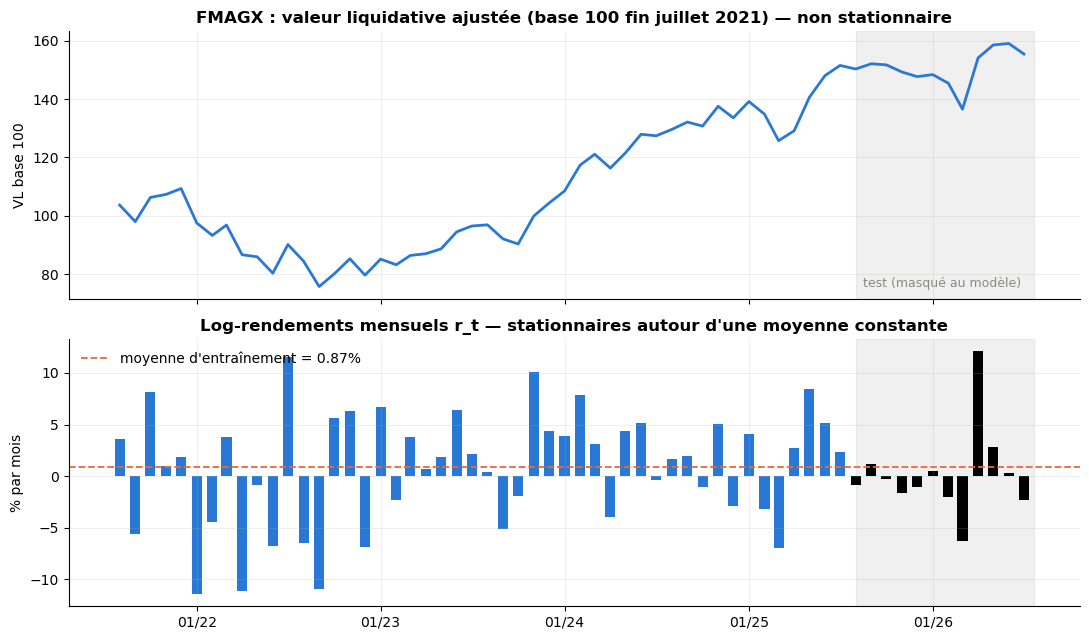

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
t_all = r.index.to_timestamp()
t_split = test.index[0].to_timestamp()
for ax in axes:
    ax.axvspan(t_split, t_all[-1] + pd.Timedelta(days=20), color=COLORS["gris"], alpha=0.12)
axes[0].plot(t_all, vl, color=COLORS["fonds"])
axes[0].set(title=f"{TICKER} : valeur liquidative ajustée (base 100 fin juillet 2021) — non stationnaire",
            ylabel="VL base 100")
axes[0].text(t_split + pd.Timedelta(days=15), vl.min(), "test (masqué au modèle)", color=COLORS["gris"], fontsize=9)
axes[1].bar(t_all, r * 100, width=20, color=np.where(r.index < test.index[0], COLORS["fonds"], "black"))
axes[1].axhline(train.mean() * 100, color=COLORS["marche"], ls="--", lw=1.3, label=f"moyenne d'entraînement = {train.mean():.2%}")
axes[1].set(title="Log-rendements mensuels r_t — stationnaires autour d'une moyenne constante", ylabel="% par mois")
axes[1].legend(loc="upper left")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%m/%y"))
plt.tight_layout(); save(fig, "fig1_vl_et_rendements"); plt.show()

**Analyse des graphiques et des statistiques**
* Stationnarité (niveau vs variations) : La valeur liquidative présente une tendance marquée (chute en 2022 puis remontée nette), ce qui la rend non stationnaire. À l'inverse, les rendements mensuels gravitent autour d'une moyenne constante sans dérive apparente : ils affichent le comportement typique d'une série stationnaire, point qu'on vérifiera avec le test ADF.
* Un signal masqué par la volatilité : Sur l'entraînement, le rendement moyen s'établit à 0,87 % par mois (~10 % annualisé) face à un écart-type de 5,6 %. Avec un ratio signal/bruit d'environ 0,16, la dispersion mensuelle domine largement la tendance de fond, ce qui rend toute prévision ponctuelle intrinsèquement très incertaine.
* Hypothèse de normalité : Le test de Jarque-Bera valide la normalité sur l'entraînement ($p \approx 0{,}37$ ; skewness de -0,45 ; kurtosis de 2,6), favorisée par le lissage mensuel et un échantillon court ($n = 48$). Sur le test ($n = 12$), l'hypothèse est en revanche rejetée ($p \approx 0{,}008$) en raison d'un seul mois exceptionnel (+12,1 % en avril 2026) qui tire fortement l'asymétrie vers le haut.
* Régime de marché sur le test : La dernière année se distingue par un rendement mensuel nettement plus faible (0,2 % contre 0,87 %) et une volatilité en retrait (15 % contre 19 % par an). Ce décalage de comportement entre entraînement et test offre un cadre d'évaluation réaliste et exigeant pour le modèle.

## 6. Volet A — Le pont avec le Projet 1 : les résidus de Fama–French sont-ils un bruit blanc ?

### Principe du test

Un bruit blanc théorique présente une moyenne nulle, une variance constante et aucune corrélation dans le temps : ses valeurs passées ne donnent aucune indication sur le futur. Si les résidus de Fama–French (FF3) suivent cette définition, le modèle a capté toute l'information exploitable issue du passé, ce qui valide l'hypothèse de non-autocorrélation des erreurs des MCO.

Pour vérifier l'absence de dépendance temporelle, on s'appuie sur la fonction d'autocorrélation ($\rho_h = \text{Corr}(\hat{\varepsilon}_t, \hat{\varepsilon}_{t-h})$) et le test de Ljung–Box, qui évalue conjointement les m premiers retards :
$$Q_{LB} = n(n + 2) \sum_{h=1}^{m} \frac{\hat{\rho}_h^2}{n - h} \sim \chi^2(m)$$
On teste ici jusqu'à m = 12 (un an de dynamique mensuelle). Si la p-valeur dépasse 5 %, l'hypothèse de bruit blanc est retenue ; en dessous de ce seuil, une structure temporelle a été manquée par le modèle factoriel, justifiant l'ajout d'une composante autorégressive (Volet B).

In [8]:
lb_ff3 = acorr_ljungbox(resid_ff3, lags=range(1, LB_LAGS + 1), return_df=True)
lb_ff3["bruit blanc (5%)"] = np.where(lb_ff3["lb_pvalue"] > SEUIL, "oui", "non")
lb12 = lb_ff3.loc[LB_LAGS]
print(f"Ljung-Box à l'ordre {LB_LAGS} sur les résidus FF3 : Q = {lb12.lb_stat:.3f}, p-value = {lb12.lb_pvalue:.4f}")
print("=> Résidus compatibles avec un bruit blanc : modèle Fama-French VALIDÉ" if lb12.lb_pvalue > SEUIL
      else "=> Autocorrélation résiduelle : dynamique omise, passer au volet B")
lb_car = acorr_ljungbox(df["resid_Carhart"], lags=[LB_LAGS], return_df=True).iloc[0]
print(f"(contrôle) Ljung-Box ordre {LB_LAGS} sur les résidus Carhart : Q = {lb_car.lb_stat:.3f}, p-value = {lb_car.lb_pvalue:.4f}")
lb_ff3.T

Ljung-Box à l'ordre 12 sur les résidus FF3 : Q = 10.024, p-value = 0.6139
=> Résidus compatibles avec un bruit blanc : modèle Fama-French VALIDÉ
(contrôle) Ljung-Box ordre 12 sur les résidus Carhart : Q = 14.840, p-value = 0.2503


,1,2,3,4,5,6,7,8,9,10,11,12
lb_stat,2.3784,3.8570,3.9292,5.6682,8.0083,8.3936,8.9461,9.0717,9.3639,9.7836,9.8097,10.0237
lb_pvalue,0.1230,0.1454,0.2692,0.2253,0.1558,0.2107,0.2566,0.3363,0.4044,0.4597,0.5476,0.6139
bruit blanc (5%),oui,oui,oui,oui,oui,oui,oui,oui,oui,oui,oui,oui


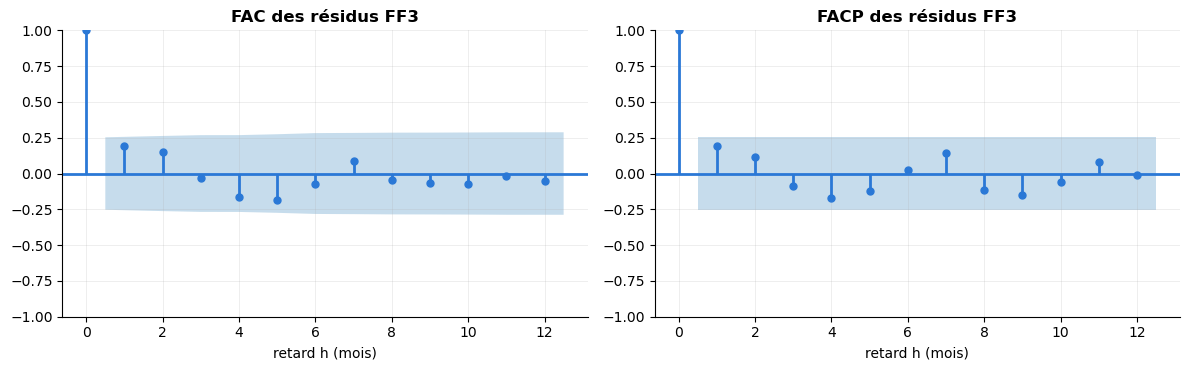

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_acf(resid_ff3, lags=LB_LAGS, ax=axes[0], color=COLORS["fonds"], vlines_kwargs={"colors": COLORS["fonds"]})
plot_pacf(resid_ff3, lags=LB_LAGS, ax=axes[1], method="ywm", color=COLORS["fonds"], vlines_kwargs={"colors": COLORS["fonds"]})
axes[0].set(title="FAC des résidus FF3", xlabel="retard h (mois)")
axes[1].set(title="FACP des résidus FF3", xlabel="retard h (mois)")
plt.tight_layout(); save(fig, "fig2_volet_A_correlogramme_residus_FF3"); plt.show()

### Vérification complémentaire : ajustement d'un ARMA sur les résidus

Pour consolider le diagnostic, on teste une grille de 16 modèles $\text{ARMA}(p, q)$ (avec $p, q \in \{0, 1, 2, 3\}$) sur la série des résidus. Si le résidu est bien un bruit blanc sans dynamique résiduelle, le critère BIC doit logiquement désigner le modèle vide $\text{ARMA}(0, 0)$.

In [10]:
def grille_arma(serie, max_p=MAX_P, max_q=MAX_Q):
    """Estime ARMA(p, q) pour toute la grille et renvoie AIC, BIC et l'indicateur de convergence de chaque modèle."""
    lignes = []
    for p, q in itertools.product(range(max_p + 1), range(max_q + 1)):
        try:
            fit = ARIMA(serie, order=(p, 0, q)).fit()
            lignes.append({"p": p, "q": q, "k = p+q+1": p + q + 1, "AIC": fit.aic, "BIC": fit.bic,
                           "convergé": bool((fit.mle_retvals or {}).get("converged", True))})
        except Exception:                      # un ordre non estimable est simplement écarté
            lignes.append({"p": p, "q": q, "k = p+q+1": p + q + 1, "AIC": np.nan, "BIC": np.nan, "convergé": False})
    return pd.DataFrame(lignes)

grille_resid = grille_arma(resid_ff3)
print("Ordre minimisant le BIC sur les résidus FF3 :", tuple(grille_resid.loc[grille_resid["BIC"].idxmin(), ["p", "q"]]))
print("Ordre minimisant l'AIC sur les résidus FF3 :", tuple(grille_resid.loc[grille_resid["AIC"].idxmin(), ["p", "q"]]))
grille_resid.sort_values("BIC").head(4).set_index(["p", "q"])

Ordre minimisant le BIC sur les résidus FF3 : (np.int64(0), np.int64(0))
Ordre minimisant l'AIC sur les résidus FF3 : (np.int64(1), np.int64(0))


k = p+q+1       AIC       BIC  convergé
p q                                         
0 0          1 -346.0694 -341.8807      True
1 0          2 -346.3958 -340.1128      True
0 1          2 -345.9025 -339.6194      True
  2          3 -345.7084 -337.3310      True

**Conclusion du volet A : validation des résidus FF3**
* Test de Ljung–Box concluant : à l'ordre 12, la statistique donne $Q \approx 10{,}0$ pour une p-valeur de 0,61, largement au-dessus du seuil de 5 %. Aucun des ordres intermédiaires (1 à 11) ne rejette le bruit blanc, et le modèle de Carhart aboutit au même constat ($p \approx 0{,}25$).
* Corrélogrammes neutres : ni la FAC ni la FACP ne franchissent la bande de confiance à 95 %. Il n'y a aucune structure AR ou MA apparente.
* Sélection ARMA : le critère BIC retient directement l'$\text{ARMA}(0, 0)$. L'AIC privilégie très légèrement un $\text{AR}(1)$, mais avec un écart minime ($\Delta\text{AIC} = 0{,}3$) non significatif, qui reflète simplement la légère corrélation d'ordre 1 déjà visible via le Durbin–Watson du Projet 1 (1,59).

**Conséquences** (1) Les écarts-types MCO du premier projet restent valables sans nécessiter de correction de Newey–West. (2) Le modèle factoriel n'omet aucune dynamique temporelle interne.

Le passage au Volet B ne vient donc pas corriger un défaut de Fama–French, mais répond à une contrainte pratique : FF3 s'appuie sur des facteurs de marché contemporains (connus après coup), alors qu'en gestion réelle, on doit prévoir sans eux. L'objectif est donc d'évaluer si l'historique du fonds seul permet d'anticiper son rendement futur.

## 7. Volet B — Backtesting : découpage, stationnarité et calibration de l'ARMA

### Le découpage entraînement / test

| Échantillon | Période | Nombre de mois | Rôle |
|---|---|---|---|
| Entraînement (80 %) | août 2021 – juillet 2025 | 48 | test ADF, corrélogramme, choix de $(p,q)$ par AIC/BIC, estimation des paramètres |
| Test (20 %) | août 2025 – juillet 2026 | 12 | comparaison des prévisions et de la réalité au volet D |

Toutes les cellules de cette section reposent exclusivement sur l'échantillon d'entraînement (`train`).

### Stationnarité : le test de Dickey–Fuller augmenté (ADF)

Un modèle de séries temporelles suppose que les propriétés statistiques passées restent valables pour le futur. Si la moyenne ou la variance évoluent au fil du temps, ces relations deviennent instables. Le test ADF permet de vérifier si la série possède une racine unitaire en estimant l'équation suivante :
$$\Delta y_t = c + \delta y_{t-1} + \sum_{j=1}^{p} \gamma_j \Delta y_{t-j} + \varepsilon_t, \quad \delta = \phi_1 - 1$$
$H_0 : \delta = 0$ ($\phi_1 = 1$), présence d'une racine unitaire (la série suit une marche aléatoire non stationnaire).
$H_1 : \delta < 0$, la série est stationnaire et effectue un retour vers sa moyenne.
Le test étant unilatéral à gauche, l'hypothèse de racine unitaire est rejetée dès que la statistique est suffisamment négative (inférieure à la valeur critique au seuil de 5 %). On applique ce diagnostic à la fois sur le log-cours $\ln P_t$ et sur le log-rendement $r_t$.

In [24]:
def adf(serie, regression, nom):
    stat, pval, nlags, nobs, crit, _ = adfuller(serie, autolag="AIC", regression=regression)
    return {"série": nom, "régression": {"c": "constante", "ct": "constante + tendance"}[regression],
            "stat ADF": stat, "p-value": pval, "retards retenus": nlags,
            "VC 1%": crit["1%"], "VC 5%": crit["5%"], "VC 10%": crit["10%"],
            "conclusion (5%)": "stationnaire (H0 rejetée)" if pval < SEUIL else "racine unitaire (H0 non rejetée)"}

log_vl_train = log_vl.loc[train.index]
adf_tab = pd.DataFrame([adf(log_vl_train, "c", "log-prix ln P_t (train)"),
                        adf(log_vl_train, "ct", "log-prix ln P_t (train)"),
                        adf(train, "c", "log-rendement r_t (train)")]).set_index(["série", "régression"])
adf_tab

stat ADF  p-value  retards retenus   VC 1%   VC 5%  VC 10%  \
série                     régression                                                                         
log-prix ln P_t (train)   constante               0.2963   0.9772                2 -3.5848 -2.9283 -2.6023   
                          constante + tendance   -2.0237   0.5885                0 -4.1656 -3.5084 -3.1841   
log-rendement r_t (train) constante              -5.3219   0.0000                1 -3.5813 -2.9268 -2.6015   

                                                                 conclusion (5%)  
série                     régression                                              
log-prix ln P_t (train)   constante             racine unitaire (H0 non rejetée)  
                          constante + tendance  racine unitaire (H0 non rejetée)  
log-rendement r_t (train) constante                    stationnaire (H0 rejetée)

**Lecture du test ADF :**

Log-cours : la présence d'une racine unitaire n'est pas rejetée ($p \approx 0{,}98$ avec constante, et $p \approx 0{,}59$ avec tendance). La statistique positive confirme que le niveau de valeur liquidative se comporte comme une marche aléatoire. Tenter de modéliser directement cette série de prix conduirait à une régression fallacieuse.
Log-rendement : la stationnarité est clairement validée avec une statistique de -5,32, nettement en dessous du seuil critique à 1 % (environ -3,58, p < 0,001). L'hypothèse de racine unitaire est donc rejetée sans ambiguïté.
On retient donc un ordre d'intégration d = 0 sur les rendements, ce qui équivaut à un modèle $\text{ARIMA}(p, 1, q)$ sur les log-cours sans nécessiter de différenciation supplémentaire.

### Corrélogramme FAC / FACP
Le corrélogramme est l'outil visuel de base pour deviner l'ordre d'un ARMA. Règle de lecture croisée :

| Signature | FAC (autocorrélation simple) | FACP (autocorrélation partielle) |
|---|---|---|
| **AR(p)** : $y_t = c + \phi_1 y_{t-1} + \dots + \phi_p y_{t-p} + \varepsilon_t$ | décroît progressivement | s'annule brutalement après le retard p |
| **MA(q)** : $y_t = \mu + \varepsilon_t + \theta_1\varepsilon_{t-1} + \dots + \theta_q\varepsilon_{t-q}$ | s'annule brutalement après le retard q | décroît progressivement |
| **ARMA(p, q)** | décroît progressivement | décroît progressivement |
| **Bruit blanc** | aucune barre significative | aucune barre significative |

La FAC au retard $h$ mesure la dépendance globale entre $y_t$ et $y_{t-h}$. La FACP isole quant à elle l'effet direct après neutralisation des retards intermédiaires, selon le principe d'une régression multiple toutes choses égales par ailleurs. Dans le cas d'un AR(1), $y_t$ n'est relié à $y_{t-2}$ qu'au travers de $y_{t-1}$ : la FAC s'atténue graduellement ($\rho_h = \phi^h$) tandis que la FACP tombe à zéro dès le deuxième décalage.
Le fuseau grisé correspond à l'intervalle de confiance à 95 % sous l'hypothèse de bruit blanc ($\approx \pm 1{,}96/\sqrt{n}$, soit $\pm 0{,}28$ pour $n = 48$). L'analyse se concentre sur 12 retards, l'échantillon de 48 observations ne permettant pas d'estimer des ordres supérieurs de façon robuste.

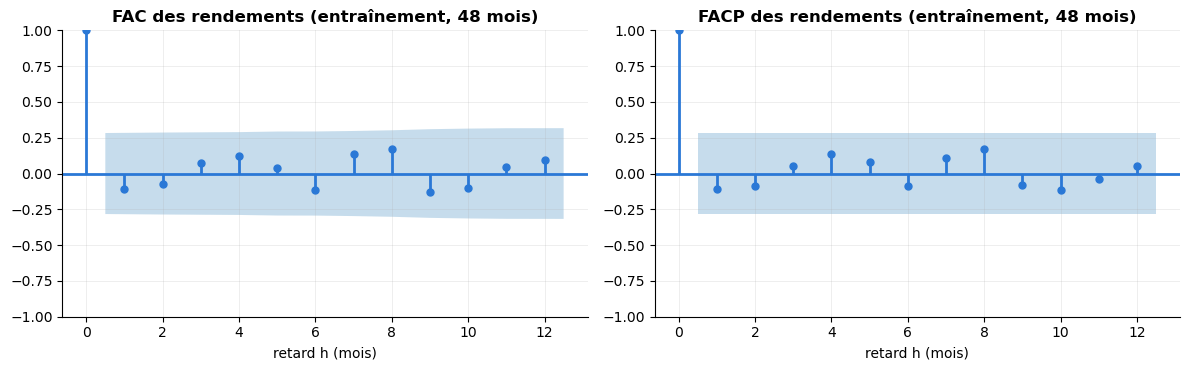

Ljung-Box sur les rendements d'entraînement (H0 : bruit blanc) :


,lb_stat,lb_pvalue
1,0.6085,0.4354
3,1.1711,0.7599
6,2.8000,0.8335
12,7.9932,0.7857


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_acf(train, lags=12, ax=axes[0], color=COLORS["fonds"], vlines_kwargs={"colors": COLORS["fonds"]})
plot_pacf(train, lags=12, ax=axes[1], method="ywm", color=COLORS["fonds"], vlines_kwargs={"colors": COLORS["fonds"]})
axes[0].set(title="FAC des rendements (entraînement, 48 mois)", xlabel="retard h (mois)")
axes[1].set(title="FACP des rendements (entraînement, 48 mois)", xlabel="retard h (mois)")
plt.tight_layout(); save(fig, "fig3_volet_B_correlogramme_rendements"); plt.show()

lb_train = acorr_ljungbox(train, lags=[1, 3, 6, 12], return_df=True)
print("Ljung-Box sur les rendements d'entraînement (H0 : bruit blanc) :")
lb_train

**Lecture des résultats :** 

Aucune barre ne franchit la zone de confiance à 95 %, que ce soit pour la FAC ou la FACP. La corrélation la plus marquée apparaît au premier retard tout en restant marginale (-0,11 contre un seuil critique à ±0,28). Le test de Ljung-Box confirme ce résultat : aucune autocorrélation n'est significative jusqu'à l'ordre 12 (p-valeur d'environ 0,79).

Ce profil correspond à celui d'un bruit blanc. L'analyse graphique ne montrant aucune structure évidente de type AR ou MA, la sélection s'appuie désormais sur les critères d'information AIC et BIC.

### Choix de l'ordre (p, q) par les critères d'information AIC et BIC

On estime les 16 combinaisons ARMA(p, q) pour p et q compris entre 0 et 3 par maximum de vraisemblance, en se limitant strictement à la période d'entraînement. La sélection repose ensuite sur deux critères :

$$AIC = -2 \ln \hat{L} + 2k, \quad BIC = -2 \ln \hat{L} + k \ln n$$

Ici, $\hat{L}$ désigne la vraisemblance maximisée et $k = p + q + 1$ le nombre de paramètres estimés, constante comprise. Le premier terme évalue la qualité d'ajustement, tandis que le second sanctionne le nombre de variables afin d'éviter le surapprentissage : un modèle trop chargé risquerait d'ajuster le bruit historique au détriment de sa capacité prédictive hors échantillon.

Le critère BIC appliquant une pénalité plus sévère ($\ln 48 \approx 3{,}9$ contre 2 pour l'AIC), il privilégie des spécifications plus sobres. On retient donc en priorité l'ordre minimisant le BIC, tout en conservant l'AIC à des fins de comparaison. La prise en compte de la variance $\sigma^2$ dans statsmodels ajoute simplement une constante identique à l'ensemble des modèles, sans modifier leur hiérarchie.

Ordre minimisant le BIC : ARMA(0,0)  (BIC = -133.97)  <- modèle retenu
Ordre minimisant l'AIC  : ARMA(0,0)  (AIC = -137.71)
Modèles dont l'optimisation n'a pas convergé : [(0, 1), (1, 2), (2, 0), (2, 2), (2, 3), (3, 1), (3, 3)]


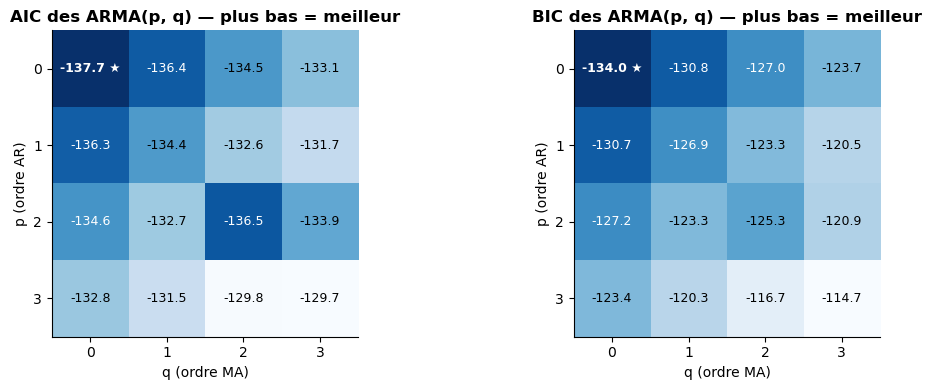

k = p+q+1       AIC       BIC  convergé
p q                                         
0 0          1 -137.7125 -133.9701      True
  1          2 -136.3718 -130.7582     False
1 0          2 -136.2800 -130.6664      True
2 0          3 -134.6426 -127.1578     False
0 2          3 -134.4825 -126.9977      True
1 1          3 -134.4128 -126.9280      True

In [26]:
grille = grille_arma(train)
best_bic = grille.loc[grille["BIC"].idxmin()]
best_aic = grille.loc[grille["AIC"].idxmin()]
P_OPT, Q_OPT = int(best_bic.p), int(best_bic.q)
print(f"Ordre minimisant le BIC : ARMA({P_OPT},{Q_OPT})  (BIC = {best_bic.BIC:.2f})  <- modèle retenu")
print(f"Ordre minimisant l'AIC  : ARMA({int(best_aic.p)},{int(best_aic.q)})  (AIC = {best_aic.AIC:.2f})")
print(f"Modèles dont l'optimisation n'a pas convergé : {[(int(a), int(b)) for a, b in grille.loc[~grille['convergé'], ['p', 'q']].values]}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, crit in zip(axes, ["AIC", "BIC"]):
    mat = grille.pivot(index="p", columns="q", values=crit)
    im = ax.imshow(mat, cmap="Blues_r")
    ax.grid(False)
    ax.set(xticks=range(MAX_Q + 1), yticks=range(MAX_P + 1), xlabel="q (ordre MA)", ylabel="p (ordre AR)",
           title=f"{crit} des ARMA(p, q) — plus bas = meilleur")
    pm, qm = np.unravel_index(np.nanargmin(mat.values), mat.shape)
    vmin, vmax = np.nanmin(mat.values), np.nanmax(mat.values)
    for i in range(MAX_P + 1):
        for j in range(MAX_Q + 1):
            fonce = (mat.iloc[i, j] - vmin) / (vmax - vmin) < 0.4        # case foncée -> texte blanc
            ax.text(j, i, f"{mat.iloc[i, j]:.1f}" + (" ★" if (i, j) == (pm, qm) else ""), ha="center", va="center",
                    fontsize=9, fontweight="bold" if (i, j) == (pm, qm) else "normal",
                    color="white" if fonce else "black")
plt.tight_layout(); save(fig, "fig4_volet_B_grille_AIC_BIC"); plt.show()

grille.sort_values("BIC").head(6).set_index(["p", "q"])

**Lecture de la grille :**

**Sélection unanime :** l'AIC et le BIC désignent tous deux le modèle ARMA(0, 0), c'est-à-dire une simple constante avec bruit blanc ($r_t = \mu + \varepsilon_t$). L'intégration de termes autorégressifs ou de moyennes mobiles n'améliore pas assez la vraisemblance pour compenser le coût de la pénalité.

**Spécifications alternatives :** les configurations MA(1) et AR(1) arrivent juste après, avec un écart d'environ 3,2 points de BIC et de 1,3 à 1,4 point d'AIC par rapport au modèle retenu. Le faible gain d'ajustement confirme l'absence de réelle dynamique temporelle dans la série.

**Modèles d'ordre supérieur :** les structures plus denses (ARMA(2, 2), (2, 3), (3, 3)...) écopent d'une forte pénalité et plusieurs n'atteignent pas la convergence numérique, l'optimiseur peinant à identifier 5 à 7 paramètres sur un échantillon court de 48 mois. Ces candidats sont logiquement mis de côté.

Ce constat concorde avec les corrélogrammes et reste cohérent avec l'hypothèse d'efficience faible des marchés : la trajectoire passée des rendements mensuels de FMAGX n'apporte pas d'information prédictive linéaire. On valide donc l'ARMA(0, 0), tout en conservant l'AR(1) et le MA(1) à titre de référence pour juger au volet D si l'ajout d'une dynamique temporelle apporte une plus-value sur la prévision.

### Estimation du modèle retenu et diagnostic de ses résidus

Un modèle ARMA est correctement spécifié si ses résidus ne contiennent plus de dépendance temporelle et se comportent comme un bruit blanc. On procède donc à une série de contrôles sur les résidus du modèle sélectionné :

**Test de Ljung–Box à l'ordre 12 :** les degrés de liberté sont ajustés du nombre de paramètres estimés (`model_df = p + q`, soit 0 ici) pour neutraliser le blanchiment mécanique induit par l'estimation.

**Test de Jarque–Bera :** il valide la normalité des résidus, hypothèse requise pour la construction des intervalles de confiance de prévision (`get_forecast`).

**Test ARCH–LM (analyse complémentaire) :** appliqué aux résidus au carré selon le principe du test de Breusch–Godfrey, il vérifie l'absence d'effets ARCH, c'est-à-dire l'absence de mémoire sur la volatilité ou de regroupement de chocs.

On ajuste également les modèles AR(1) et MA(1) afin d'examiner la significativité individuelle de leurs coefficients.

In [36]:
ORDRE = (P_OPT, 0, Q_OPT)
modele = ARIMA(train, order=ORDRE).fit()
print(modele.summary())

concurrents = {"AR(1)": (1, 0, 0), "MA(1)": (0, 0, 1)}
fits = {f"ARMA({P_OPT},{Q_OPT}) retenu (BIC)": modele}
fits.update({nom: ARIMA(train, order=o).fit() for nom, o in concurrents.items()})

lignes = []
for nom, f in fits.items():
    for param in f.params.index:
        lignes.append({"modèle": nom, "paramètre": param, "estimation": f.params[param],
                       "écart-type": f.bse[param], "p-value": f.pvalues[param]})
pd.DataFrame(lignes).set_index(["modèle", "paramètre"])

                               SARIMAX Results                                
Dep. Variable:                      r   No. Observations:                   48
Model:                          ARIMA   Log Likelihood                  70.856
Date:                Sat, 10 Oct 2026   AIC                           -137.713
Time:                        16:02:34   BIC                           -133.970
Sample:                    08-31-2021   HQIC                          -136.298
                         - 07-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0087      0.009      1.013      0.311      -0.008       0.025
sigma2         0.0031      0.001      4.052      0.000       0.002       0.005
Ljung-Box (L1) (Q):                   0.61   Jarque-

estimation  écart-type  p-value
modèle                 paramètre                                 
ARMA(0,0) retenu (BIC) const          0.0087      0.0086   0.3113
                       sigma2         0.0031      0.0008   0.0001
AR(1)                  const          0.0086      0.0080   0.2814
                       ar.L1         -0.1076      0.1460   0.4610
                       sigma2         0.0030      0.0008   0.0001
MA(1)                  const          0.0086      0.0079   0.2781
                       ma.L1         -0.1233      0.1561   0.4296
                       sigma2         0.0030      0.0008   0.0001

In [37]:
diag = []
for nom, f in fits.items():
    o = f.model.order
    lb = acorr_ljungbox(f.resid, lags=[LB_LAGS], model_df=o[0] + o[2], return_df=True).iloc[0]
    jb = stats.jarque_bera(f.resid)
    arch_stat, arch_p, _, _ = het_arch(f.resid, nlags=6)
    diag.append({"modèle": nom, "Ljung-Box Q(12)": lb.lb_stat, "p LB": lb.lb_pvalue,
                 "JB": jb.statistic, "p JB": jb.pvalue, "ARCH-LM(6) [bonus]": arch_stat, "p ARCH": arch_p,
                 "AIC": f.aic, "BIC": f.bic})
diag = pd.DataFrame(diag).set_index("modèle")
mu_hat, sigma_hat = modele.params["const"], np.sqrt(modele.params["sigma2"])
print(f"Modèle retenu : r_t = {mu_hat:.4f} + e_t,  sigma = {sigma_hat:.4f}  "
      f"(soit {12 * mu_hat:.1%}/an de rendement moyen et {np.sqrt(12) * sigma_hat:.1%}/an de volatilité)")
diag

Modèle retenu : r_t = 0.0087 + e_t,  sigma = 0.0553  (soit 10.4%/an de rendement moyen et 19.2%/an de volatilité)


,Ljung-Box Q(12),p LB,JB,p JB,ARCH-LM(6) [bonus],p ARCH,AIC,BIC
modèle,,,,,,,,
"ARMA(0,0) retenu (BIC)",7.9932,0.7857,1.9966,0.3685,18.5466,0.0050,-137.7125,-133.9701
AR(1),7.9573,0.7171,2.4561,0.2929,17.3402,0.0081,-136.2800,-130.6664
MA(1),7.6155,0.7473,2.5856,0.2745,17.7562,0.0069,-136.3718,-130.7582


**Lecture de l'estimation :**

**Modèle retenu :** l'ajustement donne $\hat{r}_t = \hat{\mu} + \varepsilon_t$ avec une moyenne mensuelle $\hat{\mu} \approx 0{,}87\ \%$ (~10,4 % par an) et un écart-type résiduel $\hat{\sigma} \approx 5{,}5\ \%$. La constante n'est pas statistiquement significative ($p \approx 0{,}31$), son intervalle de confiance à 95 % s'étendant de -0,8 % à +2,5 % par mois. L'estimation par maximum de vraisemblance s'aligne avec la moyenne empirique observée : le modèle sélectionné revient concrètement à appliquer une prévision naïve fondée sur la moyenne historique.

**Modèles comparatifs :** les paramètres de l'AR(1) ($\hat{\phi}_1 \approx -0{,}11$, $p \approx 0{,}46$) et du MA(1) ($\hat{\theta}_1 \approx -0{,}12$, $p \approx 0{,}43$) ne sont pas significatifs. Bien qu'ils respectent les critères de stationnarité et d'inversibilité ($\vert{}\hat{\phi}_1\vert{} < 1$, $\vert{}\hat{\theta}_1\vert{} < 1$), leur faible amplitude et leur manque de robustesse statistique confirment l'absence d'effet mémoire notable d'un mois sur l'autre.

**Diagnostic des résidus :**

**Test de Ljung–Box :** l'hypothèse de bruit blanc est validée pour l'ensemble des configurations ($p \approx 0{,}79$ pour l'ARMA(0, 0)). Aucune dynamique linéaire n'a été omise dans l'équation de la moyenne.

**Test de Jarque–Bera :** l'hypothèse de normalité est conservée, ce qui autorise l'usage d'intervalles de confiance gaussiens pour les projections (`get_forecast`).

**Test ARCH–LM (analyse de la variance) :** le test révèle en revanche la présence d'effets ARCH ($p \approx 0{,}005$), confirmée par le test d'hétéroscédasticité du rapport ($H \approx 0{,}31$, $p \approx 0{,}02$). La dispersion varie sensiblement selon les régimes (marché heurté en 2022 contre période plus stable en 2024), avec une variance résiduelle en fin de période réduite au tiers de son niveau initial. Le modèle capture ainsi correctement la moyenne mais ignore la structure de la variance, ce qui tendra à produire des bandes de confiance trop larges lors des accalmies et trop resserrées lors des phases de tension. Ce biais sera repris dans la discussion critique.

## 8. Volet C — Prévision sur l'horizon de test et intervalles de confiance à 95 %

### Ce que calcule `get_forecast`

Le modèle estimé sur les 48 mois d'entraînement produit, **en une seule fois depuis juillet 2025**, les prévisions des
12 mois suivants $\hat r_{T+h|T}$, $h = 1, \dots, 12$, sans jamais voir les rendements réalisés du test. Pour chaque horizon, il
donne aussi l'écart-type de l'erreur de prévision, d'où l'intervalle à 95 % :
$$\hat r_{T+h|T} \pm 1{,}96 \times \hat\sigma_{h} .$$

**À quoi s'attendre pour un ARMA(0,0) ?** Comme $r_t = \mu + \varepsilon_t$ et que les chocs futurs sont imprévisibles, la
meilleure prévision est $\hat\mu$ **à tous les horizons** : une droite horizontale. Et l'erreur de prévision est le seul
choc $\varepsilon_{T+h}$, donc $\hat\sigma_h = \hat\sigma$ pour tout $h$ : l'intervalle a **la même largeur à tous les horizons**.
Le « tunnel » qui s'élargit avec $h$ (§4.4.3) n'apparaît que lorsqu'il y a de la dynamique (AR, MA) : les erreurs se cumulent
alors d'un horizon à l'autre. Pour un AR(1), il s'élargit, mais très vite (dès $h = 2$) jusqu'à la variance totale de la série.
On verra au §9.5 que le tunnel réapparaît dès qu'on raisonne sur la **valeur liquidative**, qui cumule les rendements.

In [38]:
H = len(test)
fc = modele.get_forecast(steps=H)
prev = pd.Series(fc.predicted_mean.values, index=test.index, name="prévision")
ic = pd.DataFrame(fc.conf_int(alpha=ALPHA_IC).values, index=test.index, columns=["borne basse 95%", "borne haute 95%"])

tab_prev = pd.concat([test.rename("réalisé"), prev, ic], axis=1)
tab_prev["écart-type de prévision"] = fc.se_mean.values
tab_prev["erreur (réalisé - prévu)"] = tab_prev["réalisé"] - tab_prev["prévision"]
tab_prev["dans l'IC 95%"] = np.where((test >= ic.iloc[:, 0]) & (test <= ic.iloc[:, 1]), "oui", "NON")
couverture = (tab_prev["dans l'IC 95%"] == "oui").mean()
print(f"Modèle ARMA{ORDRE} estimé sur {train.index[0]} -> {train.index[-1]}, prévision de {test.index[0]} à {test.index[-1]}")
print(f"Taux de couverture empirique de l'IC à 95 % : {couverture:.0%} ({int(couverture * H)}/{H} mois)")

# Prévisions des modèles concurrents (même protocole)
prev_conc = {nom: pd.Series(f.get_forecast(steps=H).predicted_mean.values, index=test.index)
             for nom, f in fits.items() if nom in concurrents}
tab_prev

Modèle ARMA(0, 0, 0) estimé sur 2021-08 -> 2025-07, prévision de 2025-08 à 2026-07
Taux de couverture empirique de l'IC à 95 % : 92% (11/12 mois)


,réalisé,prévision,borne basse 95%,borne haute 95%,écart-type de prévision,erreur (réalisé - prévu),dans l'IC 95%
date_fin_de_mois,,,,,,,
2025-08,-0.0081,0.0087,-0.0997,0.1170,0.0553,-0.0168,oui
2025-09,0.0119,0.0087,-0.0997,0.1170,0.0553,0.0032,oui
2025-10,-0.0025,0.0087,-0.0997,0.1170,0.0553,-0.0111,oui
2025-11,-0.0163,0.0087,-0.0997,0.1170,0.0553,-0.0250,oui
2025-12,-0.0106,0.0087,-0.0997,0.1170,0.0553,-0.0193,oui
2026-01,0.0047,0.0087,-0.0997,0.1170,0.0553,-0.0040,oui
2026-02,-0.0202,0.0087,-0.0997,0.1170,0.0553,-0.0288,oui
2026-03,-0.0631,0.0087,-0.0997,0.1170,0.0553,-0.0717,oui
2026-04,0.1212,0.0087,-0.0997,0.1170,0.0553,0.1125,NON


**Lecture.**
* La prévision vaut **0,87 % pour chacun des 12 mois**, avec un intervalle à 95 % d'environ **[−10,0 % ; +11,7 %]**,
  identique à tous les horizons. C'est la traduction chiffrée du résultat du volet B : le modèle n'a rien d'autre à
  proposer que la moyenne.
* **Couverture :** 11 mois sur 12 tombent dans l'intervalle (92 %, pour 95 % attendus). Le seul mois hors de l'intervalle est
  **avril 2026 (+12,1 %)**, un mois de très forte hausse du marché (+9,95 % pour Mkt-RF). Avec 12 points, 11/12 est
  parfaitement compatible avec une couverture théorique de 95 %.
* **Largeur de l'intervalle :** environ 22 points de pourcentage pour une prévision de 0,9 point. L'intervalle est
  **25 fois plus large** que la prévision n'est éloignée de zéro : le modèle dit honnêtement qu'il ne sait pas si le mois
  prochain sera positif ou négatif.

## 9. Volet D — Confrontation graphique et métriques d'erreur

### Le graphique de confrontation

Le graphique réuni les éléments demandés : l'historique d'entraînement, les rendements réels observés sur le test, les prévisions de notre modèle et la zone grisé de l'intervalle de confiance à 95 %.

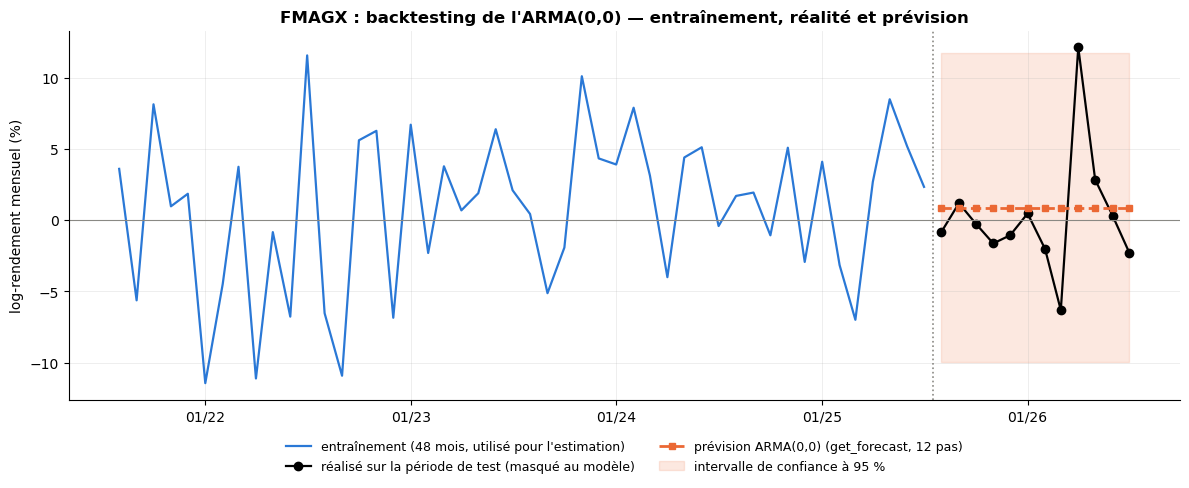

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))
t_tr, t_te = train.index.to_timestamp(), test.index.to_timestamp()
ax.plot(t_tr, train * 100, color=COLORS["fonds"], lw=1.6, label="entraînement (48 mois, utilisé pour l'estimation)")
ax.plot(t_te, test * 100, color="black", marker="o", lw=1.6, label="réalisé sur la période de test (masqué au modèle)")
ax.plot(t_te, prev * 100, color=COLORS["marche"], ls="--", marker="s", ms=4,
        label=f"prévision ARMA({P_OPT},{Q_OPT}) (get_forecast, 12 pas)")
ax.fill_between(t_te, ic.iloc[:, 0] * 100, ic.iloc[:, 1] * 100, color=COLORS["marche"], alpha=0.15,
                label="intervalle de confiance à 95 %")
ax.axvline(t_te[0] - pd.Timedelta(days=15), color=COLORS["gris"], ls=":", lw=1.2)
ax.axhline(0, color=COLORS["gris"], lw=0.8)
ax.set(title=f"{TICKER} : backtesting de l'ARMA({P_OPT},{Q_OPT}) — entraînement, réalité et prévision",
       ylabel="log-rendement mensuel (%)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%y"))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, fontsize=9)
plt.tight_layout(); save(fig, "fig5_volet_D_confrontation"); plt.show()

### Métriques d'erreur et comparaison à la prévision naïve

L'évaluation sur les 12 mois de test s'appuie sur deux indicateurs classiques :

$$RMSE = \sqrt{\frac{1}{H} \sum_{h=1}^H (r_{T+h} - \hat{r}_{T+h|T})^2}, \quad MAE = \frac{1}{H} \sum_{h=1}^H |r_{T+h} - \hat{r}_{T+h|T}|$$

Le RMSE pénalise d'avantage les gros écarts à cause du carré, tandis que le MAE donne l'erreur moyenne absolue en points de pourcentage. Comme ces valeurs brutes sont difficile à interpréter toutes seules, on les comparent à trois références simples :
* La moyenne historique des 48 mois d'entraînement.
* La dernière valeur connue (juillet 2025 répétée).
* L'hypothèse d'un rendement nul.

Un ratio RMSE inférieur à 1 montrerai que le modèle apporte un vrai gain par rapport au benchmark.

In [30]:
def metriques(reel, prevu):
    e = reel - prevu
    return {"RMSE": np.sqrt(np.mean(e ** 2)), "MAE": np.mean(np.abs(e))}

previsions = {
    f"ARMA({P_OPT},{Q_OPT}) retenu (BIC)": prev,
    **{nom: s for nom, s in prev_conc.items()},
    "Naïf : moyenne historique (train)": pd.Series(train.mean(), index=test.index),
    "Naïf : dernière valeur (juillet 2025)": pd.Series(train.iloc[-1], index=test.index),
    "Rendement nul": pd.Series(0.0, index=test.index),
}
metr = pd.DataFrame({nom: metriques(test, s) for nom, s in previsions.items()}).T
ref = metr.loc["Naïf : moyenne historique (train)"]
metr["RMSE / RMSE naïf"] = metr["RMSE"] / ref["RMSE"]
metr["MAE / MAE naïf"] = metr["MAE"] / ref["MAE"]
print(f"Écart entre la prévision ARMA et la moyenne d'entraînement : {prev.iloc[0] - train.mean():+.6f} (en décimal)")

err2 = (test - prev) ** 2
print(f"Part de la somme des erreurs au carré due au seul mois d'avril 2026 : {err2.loc['2026-04'] / err2.sum():.0%}")
metr

Écart entre la prévision ARMA et la moyenne d'entraînement : -0.000005 (en décimal)
Part de la somme des erreurs au carré due au seul mois d'avril 2026 : 59%


,RMSE,MAE,RMSE / RMSE naïf,MAE / MAE naïf
"ARMA(0,0) retenu (BIC)",0.0423,0.0291,1.0000,0.9999
AR(1),0.0423,0.0289,0.9985,0.9934
MA(1),0.0422,0.0288,0.9977,0.9906
Naïf : moyenne historique (train),0.0423,0.0291,1.0000,1.0000
Naïf : dernière valeur (juillet 2025),0.0469,0.0384,1.1079,1.3175
Rendement nul,0.0419,0.0261,0.9892,0.8962


**Lecture des métriques :**

**Modèle retenu vs moyenne naïve :** les performances de l'ARMA(0, 0) et de la moyenne historique sont quasiment identiques, avec un RMSE autour de 4,23 % et un MAE de 2,91 % par mois. C'est normal vu que le modèle estime la constante par le maximum de vraisemblance, ce qui retombe pratiquement sur la moyenne empirique. Le modèle n'apporte donc pas de réelle valeur ajoutée pour la prévision.

**Modèles AR(1) et MA(1) :** les deux alternatives ne font pas mieu. Leurs prévisions s'écartent très peu de la moyenne dès le deuxième mois et leurs scores d'erreur sont presque identiques aux autres.

**Persistance (dernière valeur) :** reconduire le rendement du dernier mois donne les plus mauvais résultats (RMSE de 4,7 %). Les données ne montrent pas d'inertie forte, ce qui confirme l'autocorrélation négative vue plus tôt.

**Rendement nul :** supposer un rendement nul fait légèrement mieu que la moyenne (RMSE de 4,19 %). C'est surtout un coup de chance statistique : l'année de test a été moins performante que l'entraînement, mais rien ne permettait de l'anticiper à l'avance.

**Impact d'avril 2026 :** ce mois atypique concentre à lui seul plus de la moitié des erreurs au carré. Sur un échantillon aussi court de 12 points, un seul évènement de marché suffit à déformer le classement, rendant les petits écarts entre modèles négligeables.

**Conclusion du volet D :** sur la période de test, aucun modèle ARMA ne parvient à battre la simple moyenne historique. Le meilleur repère pour FMAGX reste son rendement moyen de long terme, avec une marge d'erreur qui reste assez importante (environ 4 % par mois).

### Pour aller plus loin : backtest glissant à un pas

Au lieu de faire une prévision fixe à 12 mois depuis juillet 2025, on simule ici la situation réelle d'un gestionnaire qui ré-estime son modèle chaque mois en intégrant la dernière donnée reçue. On avance donc sur une fenêtre croissante : pour prévoir le mois $t$, on utilise uniquement l'historique jusqu'à $t-1$, ce qui évite toute fuite d'information.

On compare ensuite les résultats à une moyenne glissante et à la marche aléatoire, en mesurant aussi le taux de bon sens directionnel (le pourcentage de mois où le signe de la variation a été correctement anticipé).

In [31]:
def backtest_glissant(serie, n_train, ordre):
    """Prévision à 1 pas avec ré-estimation sur une fenêtre croissante : la prévision du mois k n'utilise que serie[:k]."""
    prevs = [ARIMA(serie.iloc[:k], order=ordre).fit().forecast(1).iloc[0] for k in range(n_train, len(serie))]
    return pd.Series(prevs, index=serie.index[n_train:])

glissant = {f"ARMA({P_OPT},{Q_OPT}) glissant": backtest_glissant(r, n_train, ORDRE),
            "AR(1) glissant": backtest_glissant(r, n_train, (1, 0, 0)),
            "MA(1) glissant": backtest_glissant(r, n_train, (0, 0, 1)),
            "Naïf : moyenne croissante": r.expanding().mean().shift(1).loc[test.index],
            "Naïf : dernier rendement": r.shift(1).loc[test.index]}

metr_gl = pd.DataFrame({nom: {**metriques(test, s), "bon signe": np.mean(np.sign(s) == np.sign(test))}
                        for nom, s in glissant.items()}).T
metr_gl["RMSE / RMSE naïf"] = metr_gl["RMSE"] / metr_gl.loc["Naïf : moyenne croissante", "RMSE"]
print(f"Part de mois positifs sur le test : {(test > 0).mean():.0%}")
metr_gl

Part de mois positifs sur le test : 42%


,RMSE,MAE,bon signe,RMSE / RMSE naïf
"ARMA(0,0) glissant",0.0426,0.0289,0.4167,1.0000
AR(1) glissant,0.0427,0.0299,0.3333,1.0013
MA(1) glissant,0.0425,0.0297,0.3333,0.9970
Naïf : moyenne croissante,0.0426,0.0289,0.4167,1.0000
Naïf : dernier rendement,0.0635,0.0414,0.4167,1.4907


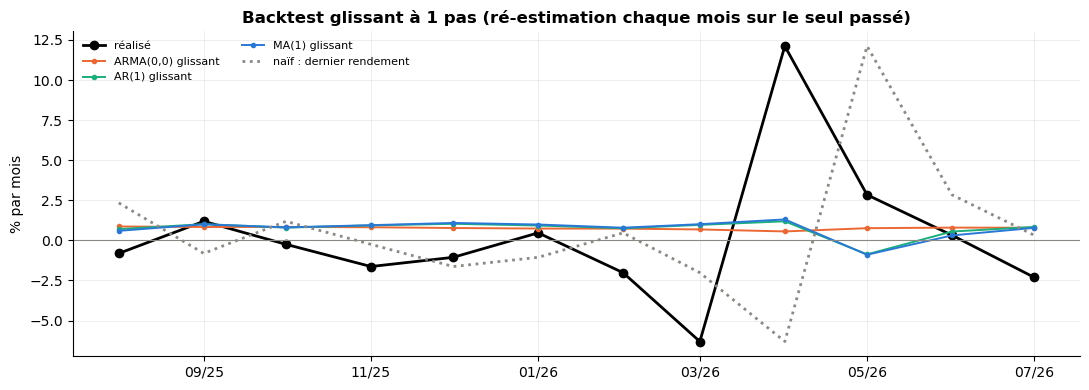

In [32]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_te, test * 100, color="black", marker="o", label="réalisé")
for (nom, s), c in zip(list(glissant.items())[:3], [COLORS["marche"], COLORS["autre"], COLORS["fonds"]]):
    ax.plot(t_te, s * 100, marker=".", lw=1.4, color=c, label=nom)
ax.plot(t_te, glissant["Naïf : dernier rendement"] * 100, color=COLORS["gris"], ls=":", label="naïf : dernier rendement")
ax.axhline(0, color=COLORS["gris"], lw=0.8)
ax.set(title="Backtest glissant à 1 pas (ré-estimation chaque mois sur le seul passé)", ylabel="% par mois")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%y")); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); save(fig, "fig6_backtest_glissant"); plt.show()

**Lecture du backtest glissant :**

**Équivalence avec la moyenne glissante :** l'ARMA(0, 0) glissant colle parfaitement à la moyenne croissante et donne des erreurs strictement similaires.

**Faible impact de la dynamique :** les versions glissantes de l'AR(1) et du MA(1) restent très proches de la moyenne. Elles n'améliorent pas le RMSE et dégradent même légérement le MAE.

**Échec de la persistance :** supposer que le mois suivant répète le précédent reste la pire stratégie, avec un RMSE montant à 6,4 %.

**Mauvaise anticipation de la direction :** les modèles fondés sur la moyenne prévoient tous des mois positifs, alors que le marché n'a monté que 5 mois sur 12 (soit 42 % de réussite sur le signe). Les modèles autorégressifs tombent même à 33 %. Utiliser ces signaux pour arbitrer le fonds n'aurait donc généré aucun gain.

### Pourquoi on ne choisit jamais le modèle sur l'échantillon de test (data snooping)

On calcul ici, à titre purement indicatif, le RMSE sur le test pour l'ensemble des 16 modèles testés. Choisir directement la configuration qui minimise l'erreur sur le test reviendrai à utiliser l'information future pour calibrer le modèle. C'est le principe même de la fuite d'information, ce qui donnerai une illusion de performance complétement faussée.

In [33]:
rmse_grille = []
for p, q in itertools.product(range(MAX_P + 1), range(MAX_Q + 1)):
    f = ARIMA(train, order=(p, 0, q)).fit()
    rmse_grille.append({"p": p, "q": q, "RMSE test (12 pas)": metriques(test, f.get_forecast(H).predicted_mean.values)["RMSE"]})
snoop = grille.merge(pd.DataFrame(rmse_grille), on=["p", "q"])
snoop["rang BIC"] = snoop["BIC"].rank().astype(int)
snoop["rang RMSE test"] = snoop["RMSE test (12 pas)"].rank().astype(int)
print(f"Corrélation de rang (Spearman) entre BIC d'entraînement et RMSE de test : "
      f"{stats.spearmanr(snoop['BIC'], snoop['RMSE test (12 pas)']).statistic:+.2f}")
snoop.sort_values("RMSE test (12 pas)").head(5).set_index(["p", "q"])[["BIC", "convergé", "RMSE test (12 pas)", "rang BIC", "rang RMSE test"]]

Corrélation de rang (Spearman) entre BIC d'entraînement et RMSE de test : +0.12


BIC  convergé  RMSE test (12 pas)  rang BIC  rang RMSE test
p q                                                                  
2 3 -120.8511     False              0.0389        12               1
  2 -125.2956     False              0.0392         7               2
3 3 -114.7304     False              0.0413        16               3
2 0 -127.1578     False              0.0422         4               4
0 2 -126.9977      True              0.0422         5               5

**Lecture :** 

Le modèle qui sort en tête sur le test est l'ARMA(2, 3) avec un RMSE de 3,89 % (contre 4,23 % pour notre modèle retenu). Pourtant, ce modèle fait partie des plus mal classé selon le critère BIC (12ème sur 16) et l'algorithme n'a même pas réussi à converger pendant l'optimisation. Les trois premiers modèles sur le test sont d'ailleur tous surparamétrés et non convergents. Leurs prévisions bougent un peu au hasard et tombent par pure chance plus près de certains mois de l'année de test, sans aucune garantie pour la suite.

D'ailleur, la corrélation de rang entre le BIC d'entraînement et le RMSE de test est quasi nulle (+0,12). Avec seulement 12 observations, l'erreur de test est bien trop bruitée pour sélectionner un modèle de façon fiable. La démarche rigoureuse consiste donc bien à choisir les ordres uniquement sur l'entraînement par le BIC, puis à tester une seule fois hors échantillon.

### Traduction en valeur liquidative : la prévision face au marché

Pour un investisseur, l'enjeu concret est d'estimer ce que donnerai un placement de 100 fait fin juillet 2025. Comme le log-prix correspond à la somme des rendements successifs, sa prévision à l'horizon $h$ s'obtient en sommant les prévisions individuelles :

$$\ln \frac{P_{T+h}}{P_T} - \sum_{j=1}^h \hat{r}_{T+j|T} = \sum_{j=1}^h e_{T+j}$$

Pour un modèle ARMA, l'erreur cumulée se décompose selon sa représentation MA infinie : $e_{T+j} = \sum_{i=0}^{j-1} \psi_i \varepsilon_{T+j-i}$. La variance de l'erreur cumulée vaut alors :

$$\sigma^2 \sum_{k=0}^{h-1} \Psi_k^2 \quad \text{avec} \quad \Psi_k = \sum_{i=0}^k \psi_i$$

Dans le cas de notre ARMA(0, 0), on a simplement $\psi_0 = 1$ et tous les autres termes sont nuls, donc la variance vaut $h \sigma^2$ et l'écart-type progresse comme $\sqrt{h}$. C'est ce qui explique le tunnel de prévision qui s'élargit avec l'horizon temporel. On superpose également la trajectoire du marché américain (Mkt-RF + RF) pour situer le fonds dans son contexte.

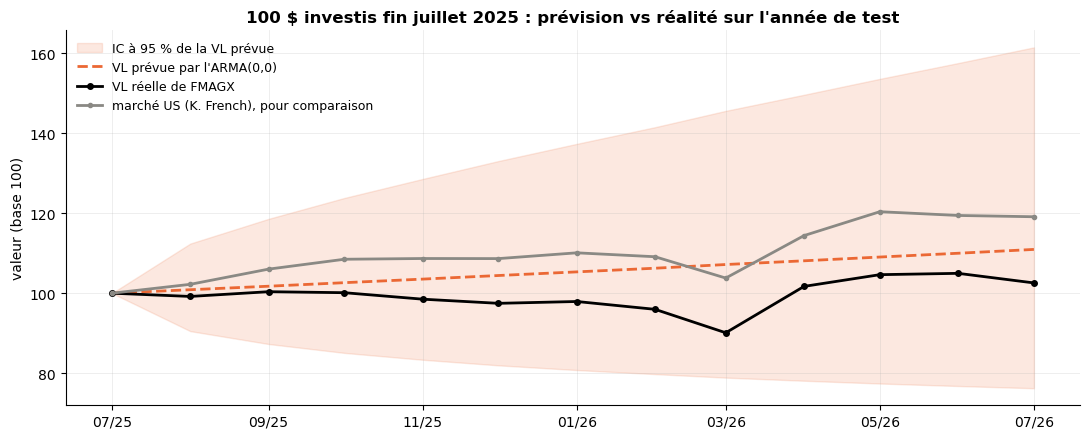

Au bout de 12 mois : VL prévue = 111.0  [IC 95 % : 76.2 ; 161.5]
                     VL réelle = 102.6 | marché US = 119.1


In [34]:
def prevision_cumulee(fit, h, alpha=ALPHA_IC):
    """Prévision du log-rendement cumulé sur 1..h mois et son IC, via les poids psi de la forme MA(infini)."""
    moy = np.cumsum(fit.get_forecast(h).predicted_mean.values)
    psi = arma2ma(fit.polynomial_ar, fit.polynomial_ma, lags=h)       # psi_0, ..., psi_{h-1}
    var = fit.params["sigma2"] * np.cumsum(np.cumsum(psi) ** 2)        # sigma^2 * somme des Psi_k^2
    z = stats.norm.ppf(1 - alpha / 2)
    return moy, moy - z * np.sqrt(var), moy + z * np.sqrt(var)

cum_moy, cum_bas, cum_haut = prevision_cumulee(modele, H)
base = 100
vl_reelle = base * np.exp(test.cumsum())
vl_prev, vl_bas, vl_haut = (base * np.exp(x) for x in (cum_moy, cum_bas, cum_haut))
marche = base * (1 + df.loc[test.index, "MKT_RF"] + df.loc[test.index, "RF"]).cumprod()

t0 = train.index[-1].to_timestamp()
tt = [t0] + list(t_te)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(tt, [base, *vl_bas], [base, *vl_haut], color=COLORS["marche"], alpha=0.15, label="IC à 95 % de la VL prévue")
ax.plot(tt, [base, *vl_prev], color=COLORS["marche"], ls="--", label=f"VL prévue par l'ARMA({P_OPT},{Q_OPT})")
ax.plot(tt, [base, *vl_reelle], color="black", marker="o", ms=4, label=f"VL réelle de {TICKER}")
ax.plot(tt, [base, *marche], color=COLORS["gris"], marker=".", label="marché US (K. French), pour comparaison")
ax.set(title="100 $ investis fin juillet 2025 : prévision vs réalité sur l'année de test", ylabel="valeur (base 100)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%y")); ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); save(fig, "fig7_tunnel_VL"); plt.show()

print(f"Au bout de 12 mois : VL prévue = {vl_prev[-1]:.1f}  [IC 95 % : {vl_bas[-1]:.1f} ; {vl_haut[-1]:.1f}]")
print(f"                     VL réelle = {vl_reelle.iloc[-1]:.1f} | marché US = {marche.iloc[-1]:.1f}")

**Lecture :**

**Trajectoire attendue :** le modèle tablait sur une valeur liquidative terminale d'environ 111 $ pour 100 $ investis, avec une fourchette à 95 % très large comprise entre 76 et 162 . Cet écartement illustre bien l'incertitude qui s'accumule avec le temps via le facteur en racine de h.

**Réalité du fonds :** le fonds termine finalement l'année vers 103  (+2,6 % sur l'année), restant bien à l'intérieur du tunnel de prévision, tout comme son point bas touché en mars 2026 à environ 90 .

**Comparaison au marché :** le marché américain a surperformé avec une valeur finale proche de 119 $ (+19 %), soit environ 16 points d'écart avec le fonds. Ce décrochage est cohérent avec l'alpha négatif mis en évidence au projet 1 (-11,5 % par an après contrôle des facteurs). Un modèle univarié sur les seuls cours passés ne pouvais pas anticiper un tel écart de style.

**Bilan pratique :** la prévision centrale apporte peu d'éléments nouveaux par rapport à la moyenne historique (~10 % par an). C'est surtout l'intervalle de confiance qui renseigne le gestionnaire : sur un an, l'éventail des scénarios va d'une perte d'environ 25 % à un gain de près de 60 %.

In [39]:
# ============ SYNTHÈSE CHIFFRÉE ============
print(f"{FUND_NAME} ({TICKER}) — entraînement {train.index[0]}->{train.index[-1]} (n={len(train)}), "
      f"test {test.index[0]}->{test.index[-1]} (n={len(test)})")
print(f"Volet A : Ljung-Box(12) résidus FF3 : Q = {lb12.lb_stat:.2f}, p = {lb12.lb_pvalue:.3f} -> modèle FF3 validé")
print(f"Volet B : ADF log-prix p = {adf_tab['p-value'].iloc[0]:.3f} (non stationnaire) | ADF rendements p = {adf_tab['p-value'].iloc[2]:.5f} (stationnaire)")
print(f"          Ordre BIC = ARMA({P_OPT},{Q_OPT}), ordre AIC = ARMA({int(best_aic.p)},{int(best_aic.q)}) | "
      f"Ljung-Box résidus p = {diag['p LB'].iloc[0]:.3f} | ARCH-LM p = {diag['p ARCH'].iloc[0]:.3f}")
print(f"Volet C : prévision = {prev.iloc[0]:.2%}/mois, IC 95 % = [{ic.iloc[0, 0]:.1%} ; {ic.iloc[0, 1]:.1%}], couverture = {couverture:.0%}")
r_m, r_n = metr.iloc[0], metr.loc["Naïf : moyenne historique (train)"]
print(f"Volet D : RMSE ARMA = {r_m.RMSE:.4f} vs naïf = {r_n.RMSE:.4f} | MAE ARMA = {r_m.MAE:.4f} vs naïf = {r_n.MAE:.4f}")

# Export des résultats (tableaux réutilisables dans le rapport)
tab_prev.to_csv(RES_DIR / "previsions_12_mois.csv")
metr.to_csv(RES_DIR / "metriques_volet_D.csv")
metr_gl.to_csv(RES_DIR / "metriques_backtest_glissant.csv")
grille.to_csv(RES_DIR / "grille_AIC_BIC.csv", index=False)
print("\nFigures :", sorted(p.name for p in FIG_DIR.glob("*.png")))
print("Résultats :", sorted(p.name for p in RES_DIR.glob("*.csv")))

Fidelity Magellan Fund (FMAGX) — entraînement 2021-08->2025-07 (n=48), test 2025-08->2026-07 (n=12)
Volet A : Ljung-Box(12) résidus FF3 : Q = 10.02, p = 0.614 -> modèle FF3 validé
Volet B : ADF log-prix p = 0.977 (non stationnaire) | ADF rendements p = 0.00000 (stationnaire)
          Ordre BIC = ARMA(0,0), ordre AIC = ARMA(0,0) | Ljung-Box résidus p = 0.786 | ARCH-LM p = 0.005
Volet C : prévision = 0.87%/mois, IC 95 % = [-10.0% ; 11.7%], couverture = 92%
Volet D : RMSE ARMA = 0.0423 vs naïf = 0.0423 | MAE ARMA = 0.0291 vs naïf = 0.0291

Figures : ['fig1_vl_et_rendements.png', 'fig2_volet_A_correlogramme_residus_FF3.png', 'fig3_volet_B_correlogramme_rendements.png', 'fig4_volet_B_grille_AIC_BIC.png', 'fig5_volet_D_confrontation.png', 'fig6_backtest_glissant.png', 'fig7_tunnel_VL.png']
Résultats : ['grille_AIC_BIC.csv', 'metriques_backtest_glissant.csv', 'metriques_volet_D.csv', 'previsions_12_mois.csv']


## 10. Bilan critique

### Réponse aux questions posées

**Volet A :** Nous validons le modèle de Fama-French du Projet 1. Ses résidus ressemblent bien à un bruit blanc (le test de Ljung-Box à l'ordre 12 donne une p-value d'environ 0,61, et il n'y a aucune autocorrélation significative). Le modèle statique ne cache donc pas de dynamique que l'on pourrait exploiter, et ses écarts-types MCO restent valides.

**Volet B :** Nous ne trouvons aucune structure ARMA dans les rendements de notre fonds. Le log-prix est clairement non stationnaire (p $\approx$ 0,98 au test ADF), alors que le rendement l'est (p < 0,001). Sur notre échantillon d'entraînement, les critères AIC et BIC s'accordent pour choisir le modèle ARMA(0,0) : le rendement mensuel n'est finalement rien de plus qu'une moyenne ($\approx$ 0,87 %/mois) additionnée à un bruit blanc ($\approx$ 5,5 %/mois).

**Volets C et D :** Nos prévisions n'ont aucune vraie valeur ajoutée. Notre modèle ARMA trace une droite à 0,87 %/mois avec un intervalle à 95 % très large (environ $\pm$ 11 points). Sur la dernière année, nos erreurs (RMSE à 4,23 % et MAE à 2,91 %) sont identiques à celles d'une simple prévision naïve basée sur la moyenne historique. L'intervalle de confiance est cependant bien calibré puisque 11 mois sur 12 tombent dedans.

**Interprétation économique.** Ce résultat "négatif" est en fait très instructif et colle parfaitement avec l'hypothèse d'efficience faible des marchés. Concrètement :

Pour un investisseur, il est impossible de trouver le "bon moment" pour acheter ce fonds en regardant juste ses performances passées.

Pour un risk manager, c'est l'intervalle de prévision (l'incertitude) qui est intéressant, pas la prévision en elle-même.

En résumé, les chocs de marché contemporains (Projet 1) expliquent le fonds, mais son passé ne permet pas de le prévoir (Projet 2).

### Ce que le modèle ne capture pas : limites assumées

* Nous avons très peu de données : Avec seulement 48 mois d'entraînement, nos tests manquent de puissance. Ne pas détecter de dynamique ne veut pas dire qu'il n'y en a absolument aucune.
* La fenêtre de test est trop courte : Tester sur 12 mois rend nos métriques très fragiles (une seule grosse erreur en avril 2026 pèse pour plus de la moitié du RMSE).
* Nous avons supposé une variance constante : Pourtant, notre test ARCH-LM a bien détecté des regroupements de volatilité (p $\approx$ 0,005). Notre modèle ARMA n'en tient pas compte, ce qui donne des intervalles trop larges quand le marché est calme et trop serrés quand il s'agite.
* Le modèle est simpliste : Il est univarié et linéaire. Il ignore complètement les informations extérieures (taux, volatilité implicite) et les potentiels changements de régime.

### Pistes d'amélioration concrètes

1. Allonger l'historique en utilisant les données du fonds FMAGX depuis 1963, ce qui permettrait de faire des tests beaucoup plus solides.
2. Passer à un modèle ARMAX en ajoutant des variables explicatives que l'on connaît à l'avance (comme le spread de taux ou la volatilité implicite VIX).
3. Modéliser la variance avec un GARCH(1,1) pour avoir des intervalles de prévision qui s'adaptent à la nervosité du marché.
4. Tester la valeur économique réelle en simulant une vraie stratégie d'investissement (nette de frais) basée sur le modèle, pour voir si elle bat une simple stratégie "acheter et conserver".